# April Forecast — Unreconciled OS-Segment Forecast vs Actuals

**Two charts.** World-level Firefox Desktop DAU split into the model's three OS populations: `modern_windows` (Win10 + Win11), `winX` (legacy Windows), `other` (Mac + Linux + everything else).

1. **Combined chart** — actuals (solid) and unreconciled forecast (dotted) overlaid on the same axes.
2. **Residual chart** — actuals minus forecast for each segment.

## Data sources

| Source | What it is | Coverage |
|---|---|---|
| **BigQuery actuals** | `moz-fx-data-shared-prod.telemetry.active_users_aggregates`, Firefox Desktop, country ≠ IR | 2025-12-04 → most-recent complete day |
| **Forecast (pkl)** | `data-official/2026-04/.../mozaic_objects.legacy_desktop.2026-04-01.pkl`. `tile.forecast_raw` summed across countries within each OS population — i.e. the raw per-tile Prophet output BEFORE the world-level reconciliation pass. | 2020-01-01 → 2027-12-31 (in-sample + forecast horizon) |

The fine-grained actuals split (Win10, Win11, WinX, Mac, Linux, Other) is kept in memory as `actuals_fine` and `actuals_fine_28ma` for drill-down.

## 28-day MA — actuals warm-up

The forecast's 28d MA at, say, April 5 needs 28 trailing days of data. The first ~27 of those days lie before FORECAST_START (2026-04-01), where the *forecast* doesn't apply. So during that warm-up window, the MA blends **actuals pre-FORECAST_START** + **forecast post-FORECAST_START** — the same blending the production composite producer uses. After ~April 28 the MA is pure forecast.

The actuals MA is just `actuals.rolling(28).mean()`. No blending needed.

## Color families

- **Blue** — modern_windows (Win10 + Win11)
- **Red** — winX (legacy Windows)
- **Green** — other (Mac + Linux + rest)

Solid = actuals; dotted = forecast.

**Display window**: 2026-03-01 → today.


In [1]:
# [setup]
import os
import sys
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from google.cloud import bigquery

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['figure.dpi'] = 110

# Walk up to the repo root so relative paths resolve regardless of launch context.
_here = Path.cwd()
for _candidate in (_here, *_here.parents):
    if (_candidate / 'src' / 'mozaic_daily').is_dir():
        os.chdir(_candidate)
        break
print(f'Working directory: {Path.cwd()}')

PKL_PATH = (
    'data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/'
    'mozaic_objects.legacy_desktop.2026-04-01.pkl'
)

FORECAST_START = pd.Timestamp('2026-04-01')
DISPLAY_START = pd.Timestamp('2026-03-01')
DISPLAY_END = pd.Timestamp.today().normalize()
# Pull actuals 28 days before March 1 so the actuals 28d MA is warm there, AND
# 28 days before FORECAST_START so the blended forecast MA at FORECAST_START is
# valid. The earlier of the two governs the BQ pull.
BQ_START = (min(DISPLAY_START, FORECAST_START) - pd.Timedelta(days=28)).strftime('%Y-%m-%d')

EXCLUDED_COUNTRIES = ['IR']

OS_POPULATIONS = ['modern_windows', 'winX', 'other']

# Color families: actuals (solid, darker) and forecast (dotted, lighter) share a hue.
SERIES_STYLE = {
    'modern_windows actuals':  dict(color='#0b3b6e', linestyle='-', linewidth=1.3),
    'modern_windows forecast': dict(color='#5a93cf', linestyle=':', linewidth=1.4),
    'winX actuals':            dict(color='#a31919', linestyle='-', linewidth=1.3),
    'winX forecast':           dict(color='#e07060', linestyle=':', linewidth=1.4),
    'other actuals':           dict(color='#1b6e3b', linestyle='-', linewidth=1.3),
    'other forecast':          dict(color='#6db671', linestyle=':', linewidth=1.4),
}
# For the residual plot we use one color per population (no actuals/forecast split).
RESIDUAL_COLOR = {
    'modern_windows': '#0b3b6e',
    'winX':           '#a31919',
    'other':          '#1b6e3b',
}
RESIDUAL_LINEWIDTH = 1.3


Working directory: /Users/brendanwells/work/mozaic-daily


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [load-pkl]
from joblib.externals import cloudpickle

t0 = time.time()
sys.stdout.write(f'Loading {PKL_PATH} ... '); sys.stdout.flush()
with open(PKL_PATH, 'rb') as f:
    mozaics = cloudpickle.load(f)
sys.stdout.write(f'{time.time() - t0:.1f}s\n')

metric_key = next(iter(mozaics))
moz = mozaics[metric_key]
print(f'Metric key: {metric_key!r}')
print(f'Tile count: {len(moz.tiles)}')
print(f'Countries:  {sorted(moz.get_countries())}')
print(f'Populations:{sorted(moz.get_populations())}')
print(f'Historical: {pd.Timestamp(min(moz.historical_dates)).date()} → {pd.Timestamp(max(moz.historical_dates)).date()}')
print(f'Forecast:   {pd.Timestamp(min(moz.forecast_dates)).date()} → {pd.Timestamp(max(moz.forecast_dates)).date()}')

Loading data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_objects.legacy_desktop.2026-04-01.pkl ... 

0.6s
Metric key: 'DAU'
Tile count: 45
Countries:  ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'ROW', 'RU', 'US']
Populations:['modern_windows', 'other', 'winX']
Historical: 2020-01-01 → 2026-04-06
Forecast:   2026-04-01 → 2027-12-31


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# [build-forecast-aggregate]
# Aggregate the 45 fitted tiles (15 countries x 3 OS populations) into a world-level
# (population, date) series of UNRECONCILED forecasts — that is, the raw per-tile
# Prophet output, summed across countries, BEFORE the world-level reconciliation
# pass that pulls each tile toward the global fit.
#
# `tile.to_df()` gives a tidy frame with columns: forecast_raw (unreconciled),
# forecast (reconciled), and the matching _28ma variants. Summing forecast_raw
# across the 15 countries inside a population is the world unreconciled forecast
# for that population.
tile_rows = []
for tile in moz.tiles:
    df = tile.to_df()[['submission_date', 'forecast_raw']].copy()
    df['population'] = tile.population
    tile_rows.append(df)
tile_long = pd.concat(tile_rows, ignore_index=True)
tile_long['submission_date'] = pd.to_datetime(tile_long['submission_date'])

forecast_by_pop = (
    tile_long.groupby(['submission_date', 'population'], as_index=False)['forecast_raw']
    .sum()
    .pivot(index='submission_date', columns='population', values='forecast_raw')
    .sort_index()
)
# 28d MA computed on the full series so values inside the display window are warm.
forecast_28ma = forecast_by_pop.rolling(28).mean()

print(f'Forecast populations: {list(forecast_by_pop.columns)}')
print(f'Forecast date range:  {forecast_by_pop.index.min().date()} → {forecast_by_pop.index.max().date()}')
print(f'\nForecast values on {FORECAST_START.date()}:')
print(forecast_by_pop.loc[FORECAST_START])


Forecast populations: ['modern_windows', 'other', 'winX']
Forecast date range:  2020-01-01 → 2027-12-31

Forecast values on 2026-04-01:
population
modern_windows    4.224173e+07
other             7.057486e+06
winX              3.225737e+06
Name: 2026-04-01 00:00:00, dtype: float64


In [4]:
# [query-actuals]
# Pull Firefox Desktop DAU from BigQuery at fine OS granularity (Win10, Win11,
# WinX, Mac, Linux, Other) and ALSO build the 3-population aggregation that
# matches the production forecast partition.
#
# We keep both:
#   - actuals_fine   : (date, fine_segment)  — for inspection / drill-down
#   - actuals_by_pop : (date, population)    — for plotting against the forecast
#
# Partition mirrors src/mozaic_daily/queries.py:
#   modern_windows = Win10 + Win11
#   winX           = Windows but not Win10/11 (Win7/8/8.1)
#   other          = Mac + Linux + Other
client = bigquery.Client(project='moz-fx-data-bq-data-science')

ACTUALS_SQL = f"""
SELECT
  submission_date AS date,
  CASE
    WHEN os_grouped = 'Windows' AND LOWER(os_version) LIKE '%windows 11%' THEN 'Win11'
    WHEN os_grouped = 'Windows' AND LOWER(os_version) LIKE '%windows 10%' THEN 'Win10'
    WHEN os_grouped = 'Windows' AND LOWER(os_version) LIKE '%windows%'    THEN 'WinX'
    WHEN os_grouped = 'Mac'   THEN 'Mac'
    WHEN os_grouped = 'Linux' THEN 'Linux'
    ELSE 'Other'
  END AS os_segment,
  SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE app_name = 'Firefox Desktop'
  AND country NOT IN ({", ".join(repr(c) for c in EXCLUDED_COUNTRIES)})
  AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
GROUP BY date, os_segment
ORDER BY date, os_segment
"""

t0 = time.time()
sys.stdout.write(f'Querying BQ actuals ({BQ_START} → today) ... '); sys.stdout.flush()
actuals_df = client.query(ACTUALS_SQL).to_dataframe()
actuals_df['date'] = pd.to_datetime(actuals_df['date'])
sys.stdout.write(f'{len(actuals_df):,} rows ({time.time() - t0:.1f}s)\n')

# Fine-grained view (one column per OS segment).
actuals_fine = actuals_df.pivot(index='date', columns='os_segment', values='dau').sort_index()

# 3-population aggregation matching the forecast partition.
FINE_TO_POP = {
    'Win10': 'modern_windows', 'Win11': 'modern_windows',
    'WinX':  'winX',
    'Mac':   'other', 'Linux': 'other', 'Other': 'other',
}
actuals_long = (
    actuals_df.assign(population=lambda d: d['os_segment'].map(FINE_TO_POP))
    .groupby(['date', 'population'], as_index=False)['dau'].sum()
)
actuals_by_pop = (
    actuals_long.pivot(index='date', columns='population', values='dau').sort_index()
)

# `active_users_aggregates` lands incrementally over several days. The most recent
# 2–4 days are typically partial — total daily DAU drops well below baseline and
# would drag the 28d MA's tail down artificially. Drop trailing days where the
# total is less than 95% of the trailing 7-day median.
total_dau = actuals_by_pop.sum(axis=1).astype(float)
rolling_med = total_dau.shift(1).rolling(7, min_periods=4).median()
completeness = total_dau / rolling_med
complete_dates = total_dau.index[completeness >= 0.95]
last_complete = complete_dates.max() if len(complete_dates) else actuals_by_pop.index.max()
n_trimmed = (actuals_by_pop.index > last_complete).sum()
if n_trimmed:
    print(f'Trimming {n_trimmed} trailing incomplete days '
          f'(after {last_complete.date()}); pre-trim last day was '
          f'{actuals_by_pop.index.max().date()}')
actuals_fine = actuals_fine.loc[actuals_fine.index <= last_complete]
actuals_by_pop = actuals_by_pop.loc[actuals_by_pop.index <= last_complete]

actuals_28ma = actuals_by_pop.rolling(28).mean()
actuals_fine_28ma = actuals_fine.rolling(28).mean()

print(f'\nFine OS segments retained: {list(actuals_fine.columns)}')
print(f'Forecast populations:      {list(actuals_by_pop.columns)}')
print(f'Date range:                {actuals_by_pop.index.min().date()} → {actuals_by_pop.index.max().date()}')

print(f'\nLast complete day ({actuals_by_pop.index.max().date()}) — fine split:')
print(actuals_fine.iloc[-1].sort_values(ascending=False))
print(f'\nLast complete day ({actuals_by_pop.index.max().date()}) — aggregated to forecast pops:')
print(actuals_by_pop.iloc[-1].sort_values(ascending=False))


Querying BQ actuals (2026-02-01 → today) ... 

678 rows (6.9s)
Trimming 2 trailing incomplete days (after 2026-05-22); pre-trim last day was 2026-05-24

Fine OS segments retained: ['Linux', 'Mac', 'Other', 'Win10', 'Win11', 'WinX']
Forecast populations:      ['modern_windows', 'other', 'winX']
Date range:                2026-02-01 → 2026-05-22

Last complete day (2026-05-22) — fine split:
os_segment
Win11    25968898
Win10    15464478
Mac       4277697
Linux     2977037
WinX      2883610
Other           4
Name: 2026-05-22 00:00:00, dtype: Int64

Last complete day (2026-05-22) — aggregated to forecast pops:
population
modern_windows    41433376
other              7254738
winX               2883610
Name: 2026-05-22 00:00:00, dtype: Int64


In [5]:
# [blend-forecast-with-actuals]
# Production behavior for the 28d MA in the early-forecast window: use ACTUALS
# for the days before FORECAST_START and FORECAST for the days from FORECAST_START
# onward. Without this, the forecast's 28d MA at, say, April 5 would average over
# Prophet's in-sample fit values (March 9–31), which approximate but don't equal
# the real data the chart's actuals line uses. Blending gives a smooth, apples-to-
# apples continuation.

# Daily blended series per population: actuals pre-FORECAST_START, forecast post.
blended_daily = pd.DataFrame(index=forecast_by_pop.index.union(actuals_by_pop.index).sort_values())
for pop in OS_POPULATIONS:
    series = pd.Series(np.nan, index=blended_daily.index, name=pop)
    if pop in actuals_by_pop.columns:
        pre = actuals_by_pop[pop].loc[actuals_by_pop[pop].index < FORECAST_START]
        series.loc[pre.index] = pre.values
    if pop in forecast_by_pop.columns:
        post = forecast_by_pop[pop].loc[forecast_by_pop[pop].index >= FORECAST_START]
        series.loc[post.index] = post.values
    blended_daily[pop] = series

# 28-day rolling MA on the blended daily series. From FORECAST_START + ~28d
# onward this is pure forecast; before that it's a smooth actuals→forecast blend.
forecast_28ma_blended = blended_daily.rolling(28).mean()

# Sanity check: blended MA should equal pure-actuals MA at the day BEFORE FORECAST_START
# (entire window is actuals), and equal pure-forecast MA well after FORECAST_START.
day_before = FORECAST_START - pd.Timedelta(days=1)
late_in_forecast = FORECAST_START + pd.Timedelta(days=60)
print('Sanity check — blended MA vs pure variants (modern_windows):')
print(f'  {day_before.date()}: blended={forecast_28ma_blended.loc[day_before, "modern_windows"]:>12,.0f} '
      f'  actuals MA={actuals_28ma.loc[day_before, "modern_windows"]:>12,.0f}   '
      f'(should match)')
print(f'  {late_in_forecast.date()}: blended={forecast_28ma_blended.loc[late_in_forecast, "modern_windows"]:>12,.0f} '
      f'  pure-forecast MA={forecast_by_pop["modern_windows"].rolling(28).mean().loc[late_in_forecast]:>12,.0f}   '
      f'(should match)')


Sanity check — blended MA vs pure variants (modern_windows):
  2026-03-31: blended=  39,560,691   actuals MA=  39,560,691   (should match)
  2026-05-31: blended=  38,994,959   pure-forecast MA=  38,994,959   (should match)


## 1. Actuals vs forecast — combined

Three pairs of lines, one per OS population. Solid = BigQuery actuals 28d MA. Dotted = unreconciled forecast 28d MA (blended with actuals for the first ~28 days post-FORECAST_START so the MA isn't dragged by in-sample fit values).


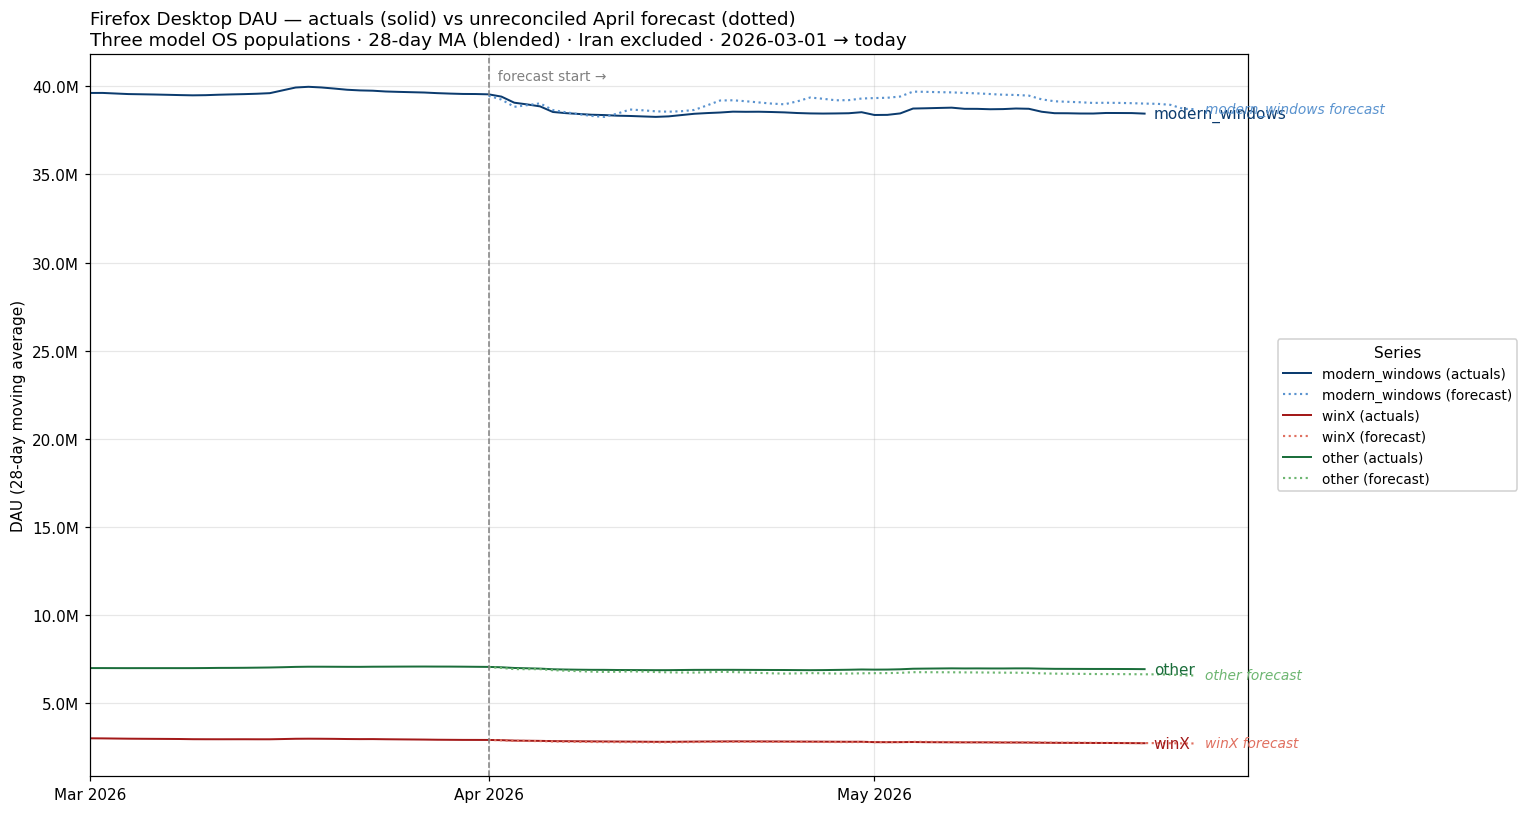

In [6]:
# [plot-combined]
# One axes, six lines: actuals (solid) and unreconciled forecast (dotted, blended
# with actuals during the early-forecast warm-up window) for each of the three
# model OS populations.

def _window(s):
    return s.loc[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]


# ── Static (matplotlib) ──────────────────────────────────────────────────────
fig_m, ax = plt.subplots(figsize=(14, 7.5))
for pop in OS_POPULATIONS:
    # Actuals — solid, full display window.
    if pop in actuals_28ma.columns:
        a = _window(actuals_28ma[pop]).dropna()
        if len(a):
            style = SERIES_STYLE[f'{pop} actuals']
            ax.plot(a.index, a.values, label=f'{pop} (actuals)', **style)
            ax.annotate(pop, xy=(a.index[-1], a.iloc[-1]), xytext=(6, 0),
                        textcoords='offset points', color=style['color'],
                        fontsize=10, va='center')

    # Forecast (blended) — dotted, plot from FORECAST_START onward.
    if pop in forecast_28ma_blended.columns:
        f = _window(forecast_28ma_blended[pop]).dropna()
        f = f.loc[f.index >= FORECAST_START]
        if len(f):
            style = SERIES_STYLE[f'{pop} forecast']
            ax.plot(f.index, f.values, label=f'{pop} (forecast)', **style)
            ax.annotate(f'{pop} forecast', xy=(f.index[-1], f.iloc[-1]), xytext=(6, 0),
                        textcoords='offset points', color=style['color'],
                        fontsize=9, fontstyle='italic', va='center')

ax.axvline(FORECAST_START, color='gray', linestyle='--', linewidth=1)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.98, '  forecast start →',
        ha='left', va='top', color='gray', fontsize=9)

ax.set_ylabel('DAU (28-day moving average)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else (f'{v/1e3:.0f}k' if v >= 1e3 else f'{v:.0f}')
))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(DISPLAY_START, DISPLAY_END + pd.Timedelta(days=4))
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, framealpha=0.9,
          title='Series')
ax.set_title('Firefox Desktop DAU — actuals (solid) vs unreconciled April forecast (dotted)\n'
             'Three model OS populations · 28-day MA (blended) · Iran excluded · 2026-03-01 → today',
             loc='left')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

# ── Interactive (plotly) ─────────────────────────────────────────────────────
fig = go.Figure()
for pop in OS_POPULATIONS:
    if pop in actuals_28ma.columns:
        a = _window(actuals_28ma[pop]).dropna()
        if len(a):
            style = SERIES_STYLE[f'{pop} actuals']
            fig.add_trace(go.Scatter(
                x=a.index, y=a.values, mode='lines',
                name=f'{pop} (actuals)',
                line=dict(color=style['color'], width=style['linewidth'], dash='solid'),
            ))
    if pop in forecast_28ma_blended.columns:
        f = _window(forecast_28ma_blended[pop]).dropna().loc[lambda s: s.index >= FORECAST_START]
        if len(f):
            style = SERIES_STYLE[f'{pop} forecast']
            fig.add_trace(go.Scatter(
                x=f.index, y=f.values, mode='lines',
                name=f'{pop} (forecast)',
                line=dict(color=style['color'], width=style['linewidth'], dash='dot'),
            ))

# add_vline is buggy with Timestamps in this plotly+pandas combo — use add_shape.
fig.add_shape(type='line', x0=FORECAST_START, x1=FORECAST_START,
              y0=0, y1=1, xref='x', yref='paper',
              line=dict(color='gray', width=1, dash='dash'))
fig.add_annotation(x=FORECAST_START, y=1.0, xref='x', yref='paper',
                   text='forecast start', showarrow=False,
                   font=dict(color='gray', size=10), xanchor='left', yanchor='bottom')
fig.update_layout(
    title='Firefox Desktop DAU — actuals vs unreconciled April forecast (by OS population)<br>'
          '<sub>solid = BigQuery actuals · dotted = pkl tile forecast summed across countries · 28d MA (blended) · no Iran</sub>',
    height=620, margin=dict(t=90, l=70, r=160, b=40),
    legend=dict(orientation='v', yanchor='top', y=1.0, xanchor='left', x=1.02),
    yaxis=dict(title='DAU (28d MA)', tickformat=',.0f'),
)
fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END + pd.Timedelta(days=4)])
fig.show()


## 2. Residual — actuals minus forecast

`residual_28ma[pop][t] = mean over [t-27, t] of (actuals[i] - forecast[i])`, computed daily then averaged — **not** `MA(actuals) − MA(blended)`. The latter is mathematically a running cumulative sum during the first 28 days of forecast, which makes it look like sawtooth noise when daily diffs have strong weekly seasonality (forecast's weekly pattern doesn't match actuals well at the modern_windows aggregate level: weekends end up −5M to −6M, weekdays +1.5M to +2.5M). The MA-of-daily-diff approach has none of that artifact.

The line is defined from FORECAST_START + 27 days onward — we need 28 valid post-forecast days to fill the MA window. Earlier days are dropped rather than shown with a partial average.


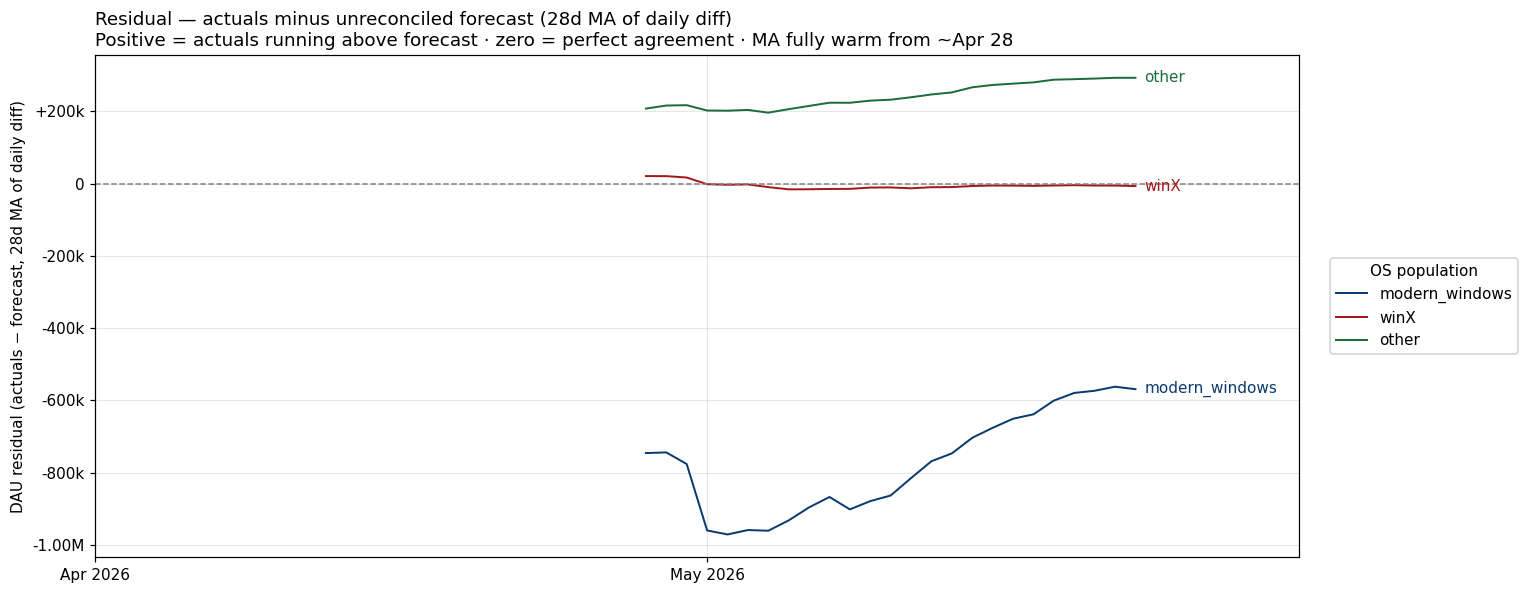


Residual at most-recent complete day (2026-05-22):
      modern_windows:       -568,813 DAU
                winX:         -7,172 DAU
               other: +       292,304 DAU


In [7]:
# [plot-residual]
# Residual = 28-day MA of daily diff (actuals - forecast), post-FORECAST_START.
#
# IMPORTANT — why we compute it this way, not `actuals_28ma - forecast_28ma_blended`:
#
# The simpler-looking `MA(actuals) - MA(blended_forecast)` is mathematically equivalent
# to `sum(actuals[i] - forecast[i] for i in [max(t-27, FORECAST_START), t]) / 28`. So
# during the first 28 days of forecast, each new daily diff gets added to a running
# cumulative sum (divided by 28) without anything coming out. If the daily diffs have
# strong weekly seasonality — as they do for desktop, where the forecast doesn't dip
# enough on weekends at the modern_windows aggregate level (weekends are -5M to -6M,
# weekdays are +1.5M to +2.5M) — the residual ends up looking like sawtooth noise
# until the window is fully populated at ~FORECAST_START+28d. That's an artifact of
# the MA-of-MAs formula, not a real divergence.
#
# Taking the 28-day MA of the daily diff directly averages over a full 4-week window,
# fully cancelling weekly seasonality. The residual is then only defined from
# FORECAST_START + 27 days onward (we need 28 valid days behind us), but the plot
# is meaningful from day one of its display.

# Daily diff post-FORECAST_START where both actuals and forecast exist.
daily_diff = pd.DataFrame(index=actuals_by_pop.index, columns=OS_POPULATIONS, dtype=float)
for pop in OS_POPULATIONS:
    if pop in actuals_by_pop.columns and pop in forecast_by_pop.columns:
        a = actuals_by_pop[pop]
        f = forecast_by_pop[pop].reindex(a.index)
        diff = a - f
        # Drop pre-FORECAST_START — diffs there are vs Prophet's in-sample fit, not the forecast.
        diff = diff.where(diff.index >= FORECAST_START)
        daily_diff[pop] = diff

# 28-day rolling MA. Default min_periods=window ensures the line only appears when
# the window is fully warm (avoids the jagged warm-up artifact).
residual_28ma = daily_diff.rolling(28).mean()


def _window_post_warmup(s):
    return s.loc[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)]


# ── Static (matplotlib) ──────────────────────────────────────────────────────
fig_m, ax = plt.subplots(figsize=(14, 5.5))
for pop in OS_POPULATIONS:
    r = _window_post_warmup(residual_28ma[pop]).dropna()
    if len(r):
        color = RESIDUAL_COLOR[pop]
        ax.plot(r.index, r.values, label=pop, color=color, linewidth=RESIDUAL_LINEWIDTH)
        ax.annotate(pop, xy=(r.index[-1], r.iloc[-1]), xytext=(6, 0),
                    textcoords='offset points', color=color,
                    fontsize=10, va='center')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('DAU residual (actuals − forecast, 28d MA of daily diff)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: ('+' if v > 0 else '') + (
        f'{v/1e6:.2f}M' if abs(v) >= 1e6 else (f'{v/1e3:.0f}k' if abs(v) >= 1e3 else f'{v:.0f}')
    )
))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(FORECAST_START, DISPLAY_END + pd.Timedelta(days=4))
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, framealpha=0.9,
          title='OS population')
ax.set_title('Residual — actuals minus unreconciled forecast (28d MA of daily diff)\n'
             'Positive = actuals running above forecast · zero = perfect agreement · MA fully warm from ~Apr 28',
             loc='left')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

# Print last-day residual values for the record.
last_day = residual_28ma.dropna().index.max()
print(f'\nResidual at most-recent complete day ({last_day.date()}):')
for pop in OS_POPULATIONS:
    val = residual_28ma.loc[last_day, pop]
    sign = '+' if val >= 0 else ''
    print(f'  {pop:>18}: {sign}{val:>14,.0f} DAU')

# ── Interactive (plotly) ─────────────────────────────────────────────────────
fig = go.Figure()
for pop in OS_POPULATIONS:
    r = _window_post_warmup(residual_28ma[pop]).dropna()
    if len(r):
        color = RESIDUAL_COLOR[pop]
        fig.add_trace(go.Scatter(
            x=r.index, y=r.values, mode='lines', name=pop,
            line=dict(color=color, width=RESIDUAL_LINEWIDTH),
        ))
fig.add_shape(type='line', x0=FORECAST_START, x1=DISPLAY_END,
              y0=0, y1=0, xref='x', yref='y',
              line=dict(color='gray', width=1, dash='dash'))
fig.update_layout(
    title='Residual — actuals minus unreconciled forecast (28d MA of daily diff)<br>'
          '<sub>positive = actuals above forecast · negative = forecast above actuals</sub>',
    height=440, margin=dict(t=80, l=70, r=120, b=40),
    legend=dict(orientation='v', yanchor='top', y=1.0, xanchor='left', x=1.02),
    yaxis=dict(title='DAU residual', tickformat=',.0f'),
)
fig.update_xaxes(range=[FORECAST_START, DISPLAY_END + pd.Timedelta(days=4)])
fig.show()


## 3. Reconciled forecast — same charts, with reconciliation applied

The two charts above use `tile.forecast_raw` — each tile's Prophet output before reconciliation. The two below use `tile.forecast` — the same tiles after the world-level Mozaic reconciliation pass has pulled them toward the global fit. Other than swapping `forecast_raw` → `forecast`, the construction is identical (sum across countries inside each population, blend with actuals for the 28d MA warm-up, plot).

Comparing the two pairs side-by-side tells you how much the reconciliation step is moving each segment.


In [8]:
# [build-reconciled-aggregate]
# Same shape as the raw forecast build above, but using tile.to_df()['forecast'] —
# the post-reconciliation per-tile values — instead of 'forecast_raw'.
tile_rows_rec = []
for tile in moz.tiles:
    df = tile.to_df()[['submission_date', 'forecast']].copy()
    df['population'] = tile.population
    tile_rows_rec.append(df)
tile_long_rec = pd.concat(tile_rows_rec, ignore_index=True)
tile_long_rec['submission_date'] = pd.to_datetime(tile_long_rec['submission_date'])

forecast_rec_by_pop = (
    tile_long_rec.groupby(['submission_date', 'population'], as_index=False)['forecast']
    .sum()
    .pivot(index='submission_date', columns='population', values='forecast')
    .sort_index()
)

# Blend with actuals (same logic as the raw blend cell).
blended_rec_daily = pd.DataFrame(
    index=forecast_rec_by_pop.index.union(actuals_by_pop.index).sort_values()
)
for pop in OS_POPULATIONS:
    series = pd.Series(np.nan, index=blended_rec_daily.index, name=pop)
    if pop in actuals_by_pop.columns:
        pre = actuals_by_pop[pop].loc[actuals_by_pop[pop].index < FORECAST_START]
        series.loc[pre.index] = pre.values
    if pop in forecast_rec_by_pop.columns:
        post = forecast_rec_by_pop[pop].loc[forecast_rec_by_pop[pop].index >= FORECAST_START]
        series.loc[post.index] = post.values
    blended_rec_daily[pop] = series

forecast_rec_28ma_blended = blended_rec_daily.rolling(28).mean()

# Daily diff for the residual chart — same construction as the raw version.
daily_diff_rec = pd.DataFrame(index=actuals_by_pop.index, columns=OS_POPULATIONS, dtype=float)
for pop in OS_POPULATIONS:
    if pop in actuals_by_pop.columns and pop in forecast_rec_by_pop.columns:
        a = actuals_by_pop[pop]
        f = forecast_rec_by_pop[pop].reindex(a.index)
        diff = (a - f).where(a.index >= FORECAST_START)
        daily_diff_rec[pop] = diff
residual_rec_28ma = daily_diff_rec.rolling(28).mean()

print(f'Reconciled forecast populations: {list(forecast_rec_by_pop.columns)}')
print(f'On {FORECAST_START.date()}:')
print(forecast_rec_by_pop.loc[FORECAST_START])


Reconciled forecast populations: ['modern_windows', 'other', 'winX']
On 2026-04-01:
population
modern_windows    4.299860e+07
other             7.180587e+06
winX              3.293194e+06
Name: 2026-04-01 00:00:00, dtype: float64


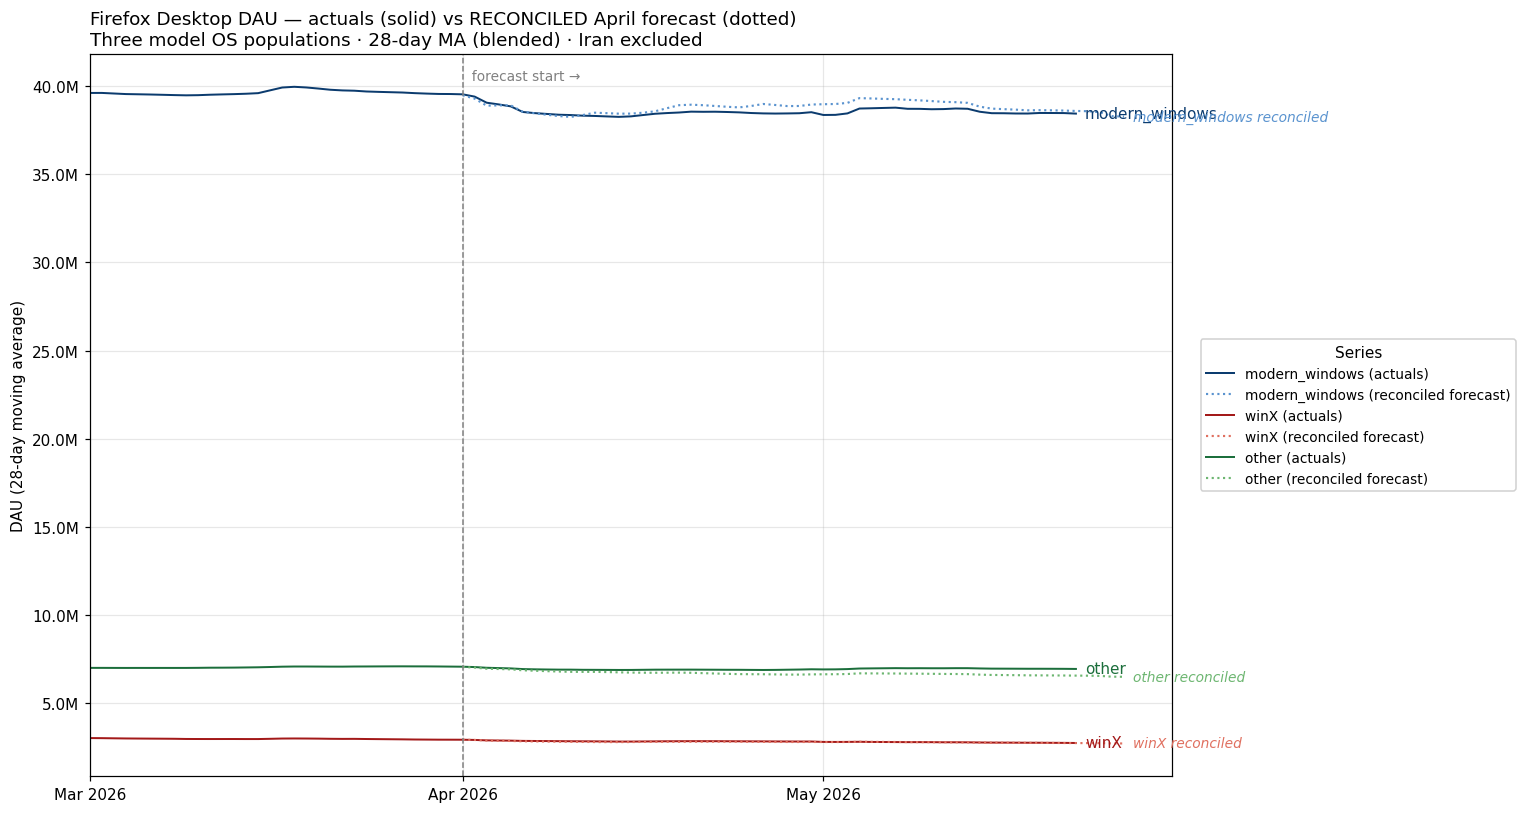

In [9]:
# [plot-combined-reconciled]
# Same as plot-combined above, with `forecast_rec_28ma_blended` swapped in for the
# unreconciled forecast.

def _window(s):
    return s.loc[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]


# ── Static (matplotlib) ──────────────────────────────────────────────────────
fig_m, ax = plt.subplots(figsize=(14, 7.5))
for pop in OS_POPULATIONS:
    if pop in actuals_28ma.columns:
        a = _window(actuals_28ma[pop]).dropna()
        if len(a):
            style = SERIES_STYLE[f'{pop} actuals']
            ax.plot(a.index, a.values, label=f'{pop} (actuals)', **style)
            ax.annotate(pop, xy=(a.index[-1], a.iloc[-1]), xytext=(6, 0),
                        textcoords='offset points', color=style['color'],
                        fontsize=10, va='center')
    if pop in forecast_rec_28ma_blended.columns:
        f = _window(forecast_rec_28ma_blended[pop]).dropna()
        f = f.loc[f.index >= FORECAST_START]
        if len(f):
            style = SERIES_STYLE[f'{pop} forecast']
            ax.plot(f.index, f.values, label=f'{pop} (reconciled forecast)', **style)
            ax.annotate(f'{pop} reconciled', xy=(f.index[-1], f.iloc[-1]), xytext=(6, 0),
                        textcoords='offset points', color=style['color'],
                        fontsize=9, fontstyle='italic', va='center')

ax.axvline(FORECAST_START, color='gray', linestyle='--', linewidth=1)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.98, '  forecast start →',
        ha='left', va='top', color='gray', fontsize=9)

ax.set_ylabel('DAU (28-day moving average)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else (f'{v/1e3:.0f}k' if v >= 1e3 else f'{v:.0f}')
))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(DISPLAY_START, DISPLAY_END + pd.Timedelta(days=4))
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, framealpha=0.9,
          title='Series')
ax.set_title('Firefox Desktop DAU — actuals (solid) vs RECONCILED April forecast (dotted)\n'
             'Three model OS populations · 28-day MA (blended) · Iran excluded',
             loc='left')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

# ── Interactive (plotly) ─────────────────────────────────────────────────────
fig = go.Figure()
for pop in OS_POPULATIONS:
    if pop in actuals_28ma.columns:
        a = _window(actuals_28ma[pop]).dropna()
        if len(a):
            style = SERIES_STYLE[f'{pop} actuals']
            fig.add_trace(go.Scatter(
                x=a.index, y=a.values, mode='lines',
                name=f'{pop} (actuals)',
                line=dict(color=style['color'], width=style['linewidth'], dash='solid'),
            ))
    if pop in forecast_rec_28ma_blended.columns:
        f = _window(forecast_rec_28ma_blended[pop]).dropna().loc[lambda s: s.index >= FORECAST_START]
        if len(f):
            style = SERIES_STYLE[f'{pop} forecast']
            fig.add_trace(go.Scatter(
                x=f.index, y=f.values, mode='lines',
                name=f'{pop} (reconciled forecast)',
                line=dict(color=style['color'], width=style['linewidth'], dash='dot'),
            ))

fig.add_shape(type='line', x0=FORECAST_START, x1=FORECAST_START,
              y0=0, y1=1, xref='x', yref='paper',
              line=dict(color='gray', width=1, dash='dash'))
fig.add_annotation(x=FORECAST_START, y=1.0, xref='x', yref='paper',
                   text='forecast start', showarrow=False,
                   font=dict(color='gray', size=10), xanchor='left', yanchor='bottom')
fig.update_layout(
    title='Firefox Desktop DAU — actuals vs RECONCILED April forecast (by OS population)<br>'
          '<sub>solid = BigQuery actuals · dotted = pkl tile.forecast (reconciled) summed across countries · 28d MA (blended) · no Iran</sub>',
    height=620, margin=dict(t=90, l=70, r=160, b=40),
    legend=dict(orientation='v', yanchor='top', y=1.0, xanchor='left', x=1.02),
    yaxis=dict(title='DAU (28d MA)', tickformat=',.0f'),
)
fig.update_xaxes(range=[DISPLAY_START, DISPLAY_END + pd.Timedelta(days=4)])
fig.show()


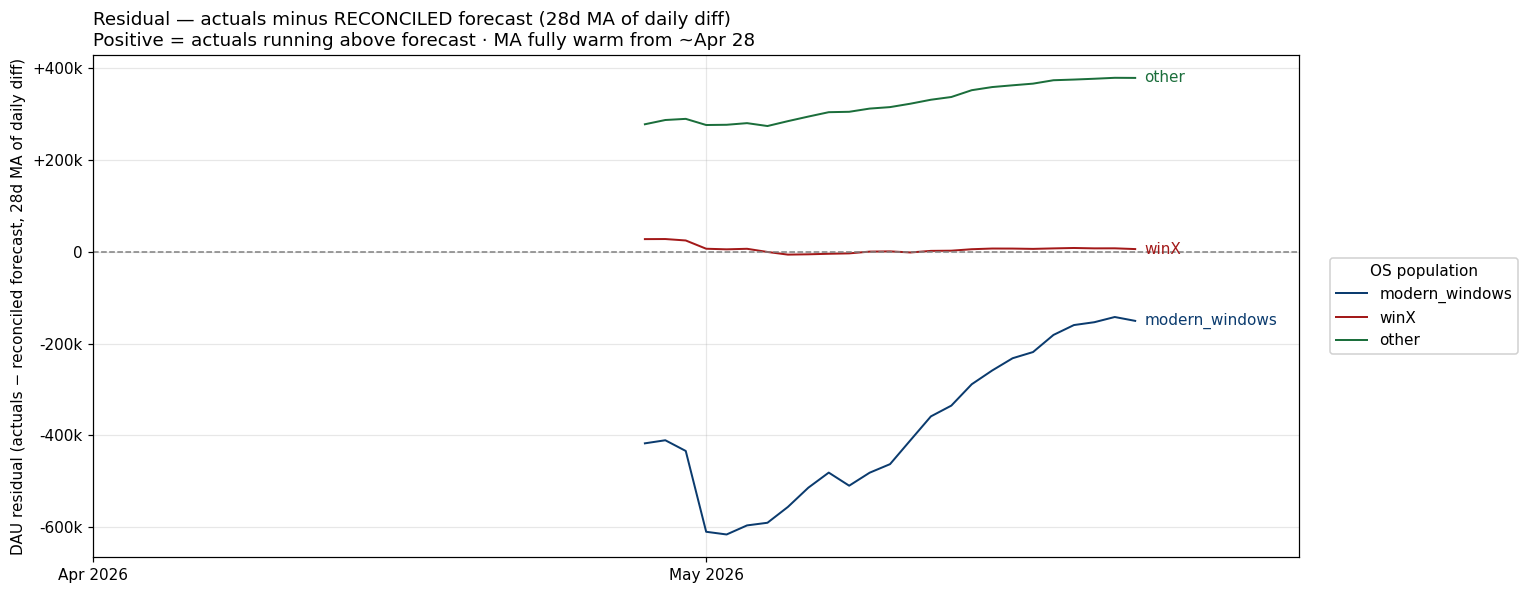


Reconciled residual at most-recent complete day (2026-05-22):
      modern_windows:       -150,631 DAU
                winX: +         5,786 DAU
               other: +       378,721 DAU


In [10]:
# [plot-residual-reconciled]
# Same calculation as plot-residual above (28d MA of daily diff, NOT MA-of-MAs),
# with the reconciled forecast in place of the unreconciled one.

def _window_post_warmup(s):
    return s.loc[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)]


# ── Static (matplotlib) ──────────────────────────────────────────────────────
fig_m, ax = plt.subplots(figsize=(14, 5.5))
for pop in OS_POPULATIONS:
    r = _window_post_warmup(residual_rec_28ma[pop]).dropna()
    if len(r):
        color = RESIDUAL_COLOR[pop]
        ax.plot(r.index, r.values, label=pop, color=color, linewidth=RESIDUAL_LINEWIDTH)
        ax.annotate(pop, xy=(r.index[-1], r.iloc[-1]), xytext=(6, 0),
                    textcoords='offset points', color=color,
                    fontsize=10, va='center')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('DAU residual (actuals − reconciled forecast, 28d MA of daily diff)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: ('+' if v > 0 else '') + (
        f'{v/1e6:.2f}M' if abs(v) >= 1e6 else (f'{v/1e3:.0f}k' if abs(v) >= 1e3 else f'{v:.0f}')
    )
))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(FORECAST_START, DISPLAY_END + pd.Timedelta(days=4))
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, framealpha=0.9,
          title='OS population')
ax.set_title('Residual — actuals minus RECONCILED forecast (28d MA of daily diff)\n'
             'Positive = actuals running above forecast · MA fully warm from ~Apr 28',
             loc='left')
fig_m.tight_layout()
plt.show()
plt.close(fig_m)

last_day = residual_rec_28ma.dropna().index.max()
print(f'\nReconciled residual at most-recent complete day ({last_day.date()}):')
for pop in OS_POPULATIONS:
    val = residual_rec_28ma.loc[last_day, pop]
    sign = '+' if val >= 0 else ''
    print(f'  {pop:>18}: {sign}{val:>14,.0f} DAU')

# ── Interactive (plotly) ─────────────────────────────────────────────────────
fig = go.Figure()
for pop in OS_POPULATIONS:
    r = _window_post_warmup(residual_rec_28ma[pop]).dropna()
    if len(r):
        color = RESIDUAL_COLOR[pop]
        fig.add_trace(go.Scatter(
            x=r.index, y=r.values, mode='lines', name=pop,
            line=dict(color=color, width=RESIDUAL_LINEWIDTH),
        ))
fig.add_shape(type='line', x0=FORECAST_START, x1=DISPLAY_END,
              y0=0, y1=0, xref='x', yref='y',
              line=dict(color='gray', width=1, dash='dash'))
fig.update_layout(
    title='Residual — actuals minus RECONCILED forecast (28d MA of daily diff)<br>'
          '<sub>positive = actuals above forecast · negative = forecast above actuals</sub>',
    height=440, margin=dict(t=80, l=70, r=120, b=40),
    legend=dict(orientation='v', yanchor='top', y=1.0, xanchor='left', x=1.02),
    yaxis=dict(title='DAU residual', tickformat=',.0f'),
)
fig.update_xaxes(range=[FORECAST_START, DISPLAY_END + pd.Timedelta(days=4)])
fig.show()
